# 07 — Results report

Aggregate and report all experiment results from the 2×2 ablation: **reduction** (autoencoder vs structured pooling) × **classifier** (MLP vs FT-Transformer). Loads saved metrics and confusion matrices from `experiments/<condition>/`, reports test and validation metrics (weighted F1, per-class Precision/Recall/F1/Support with correct Ns), and displays confusion matrices for comparison.

In [1]:
# Path fix: use this repo's src
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import get_experiment_dir
from src.data import CLASS_NAMES

# Four conditions in the 2×2 design
CONDITIONS = [
    ("A1_autoencoder_mlp", "A1: Autoencoder + MLP"),
    ("A2_autoencoder_ft", "A2: Autoencoder + FT-Transformer"),
    ("B1_pooling_mlp", "B1: Pooling + MLP"),
    ("B2_pooling_ft", "B2: Pooling + FT-Transformer"),
]
print("Class names:", CLASS_NAMES)
print("Conditions:", [c[0] for c in CONDITIONS])

Class names: ['AF', 'SVT', 'Sinus Brady', 'Sinus Rhythm']
Conditions: ['A1_autoencoder_mlp', 'A2_autoencoder_ft', 'B1_pooling_mlp', 'B2_pooling_ft']


## Dataset split sizes

Train/validation/test partition used by all experiments (from `splits.npz`). Validation and test metrics use these Ns.

In [2]:
from src.data.splits import load_splits

idx_train, idx_val, idx_test = load_splits()
n_train, n_val, n_test = len(idx_train), len(idx_val), len(idx_test)
print("Train: %d  |  Validation: %d  |  Test: %d" % (n_train, n_val, n_test))

Train: 36120  |  Validation: 2257  |  Test: 6773


## Load all experiment metrics

For each condition, load `metrics.json` and test confusion matrix from `experiments/<condition>/`. Skip conditions that have not been run yet.

In [3]:
# Load metrics and confusion matrices for each condition
all_results = {}
for cond_id, cond_label in CONDITIONS:
    exp_dir = get_experiment_dir(cond_id)
    metrics_path = exp_dir / "metrics.json"
    cm_path = exp_dir / "confusion_matrix.npy"
    if not metrics_path.exists():
        print("Skipping %s (no metrics.json)" % cond_id)
        continue
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)
    cm = np.load(cm_path) if cm_path.exists() else None
    all_results[cond_id] = {"label": cond_label, "metrics": metrics, "confusion_matrix": cm}
    print("Loaded: %s" % cond_id)
print("\nFound %d experiment(s)." % len(all_results))

Loaded: A1_autoencoder_mlp
Loaded: A2_autoencoder_ft
Loaded: B1_pooling_mlp
Loaded: B2_pooling_ft

Found 4 experiment(s).


## Summary: weighted F1 (test and validation)

Comparison of primary metric across all run conditions. Test and validation use the split Ns above.

In [4]:
# Summary table: Weighted F1
rows = []
for cond_id, cond_label in CONDITIONS:
    if cond_id not in all_results:
        continue
    m = all_results[cond_id]["metrics"]
    rows.append({
        "Condition": all_results[cond_id]["label"],
        "Test weighted F1": m.get("weighted_f1"),
        "Val weighted F1": m.get("weighted_f1_val"),
    })
df_summary = pd.DataFrame(rows)
display(df_summary)

,Condition,Test weighted F1,Val weighted F1
0,A1: Autoencoder + MLP,0.910274,0.902039
1,A2: Autoencoder + FT-Transformer,0.576950,0.561894
2,B1: Pooling + MLP,0.908806,0.904573
3,B2: Pooling + FT-Transformer,0.560937,0.550094


## Per-condition: full test and validation metrics

For each condition, report **test** and **validation** weighted F1 and per-class Precision, Recall, F1, and **Support** (the N per class on that split).

In [5]:
def print_metrics_block(metrics, split_name, per_class_key="per_class"):
    """Print weighted F1 and per-class table for one split (test or val)."""
    wf1_key = "weighted_f1" if split_name == "Test" else "weighted_f1_val"
    wf1 = metrics.get(wf1_key)
    if wf1 is None:
        return
    print("  %s weighted F1: %.4f" % (split_name, wf1))
    per = metrics.get(per_class_key, [])
    if not per:
        return
    print("  %s per-class (Precision, Recall, F1, Support):" % split_name)
    print("    %-12s %8s %8s %8s %8s" % ("Class", "Precision", "Recall", "F1", "Support"))
    print("    " + "-" * 48)
    for p in per:
        print("    %-12s %8.3f %8.3f %8.3f %8d" % (
            p["class"], p["precision"], p["recall"], p["f1"], p["support"]))

for cond_id, cond_label in CONDITIONS:
    if cond_id not in all_results:
        continue
    m = all_results[cond_id]["metrics"]
    print("\n" + "=" * 60)
    print("  %s" % all_results[cond_id]["label"])
    print("=" * 60)
    print_metrics_block(m, "Test", per_class_key="per_class")
    print_metrics_block(m, "Validation", per_class_key="per_class_val")
print("\n" + "=" * 60)


  A1: Autoencoder + MLP
  Test weighted F1: 0.9103
  Test per-class (Precision, Recall, F1, Support):
    Class        Precision   Recall       F1  Support
    ------------------------------------------------
    AF              0.910    0.907    0.909     2969
    SVT             0.544    0.568    0.556      162
    Sinus Brady     0.951    0.973    0.962     2449
    Sinus Rhythm    0.876    0.837    0.856     1193
  Validation weighted F1: 0.9020
  Validation per-class (Precision, Recall, F1, Support):
    Class        Precision   Recall       F1  Support
    ------------------------------------------------
    AF              0.893    0.900    0.897      992
    SVT             0.429    0.450    0.439       60
    Sinus Brady     0.957    0.970    0.964      811
    Sinus Rhythm    0.884    0.835    0.859      394

  A2: Autoencoder + FT-Transformer
  Test weighted F1: 0.5770
  Test per-class (Precision, Recall, F1, Support):
    Class        Precision   Recall       F1  Support
 

## Test set confusion matrices

Confusion matrices (test set) for each condition. Rows = true class, columns = predicted class.

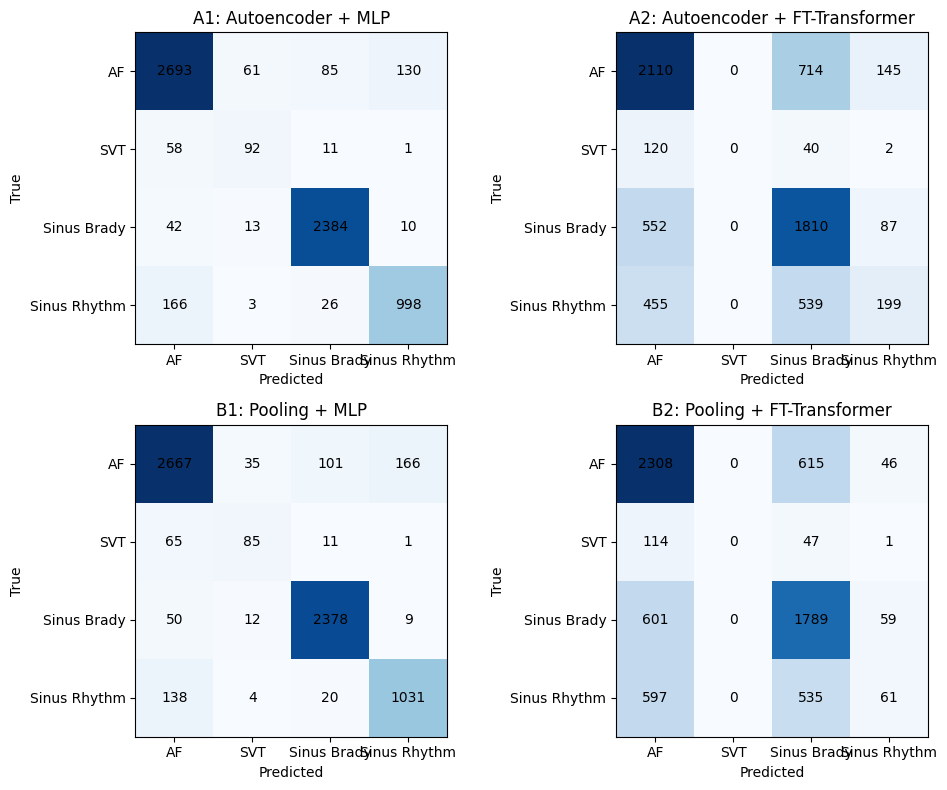

In [6]:
# Plot 2×2 grid of confusion matrices (test set)
run_conditions = [c for c in CONDITIONS if c[0] in all_results]
n_cond = len(run_conditions)
if n_cond == 0:
    print("No results to plot.")
else:
    n_cols = 2
    n_rows = (n_cond + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_cond == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    for idx, (cond_id, _) in enumerate(run_conditions):
        row, col = idx // n_cols, idx % n_cols
        ax = axes[row, col]
        cm = all_results[cond_id]["confusion_matrix"]
        if cm is not None:
            im = ax.imshow(cm, cmap="Blues")
            n = cm.shape[0]
            ax.set_xticks(range(n))
            ax.set_yticks(range(n))
            ax.set_xticklabels(CLASS_NAMES)
            ax.set_yticklabels(CLASS_NAMES)
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
            for i in range(n):
                for j in range(n):
                    ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
            ax.set_title(all_results[cond_id]["label"])
        else:
            ax.text(0.5, 0.5, "No CM", ha="center", va="center")
    for idx in range(n_cond, n_rows * n_cols):
        row, col = idx // n_cols, idx % n_cols
        axes[row, col].set_visible(False)
    plt.tight_layout()
    plt.show()

## Normalized confusion matrices (test set)

Each row normalized to sum to 1 (proportion of true class predicted as each class).

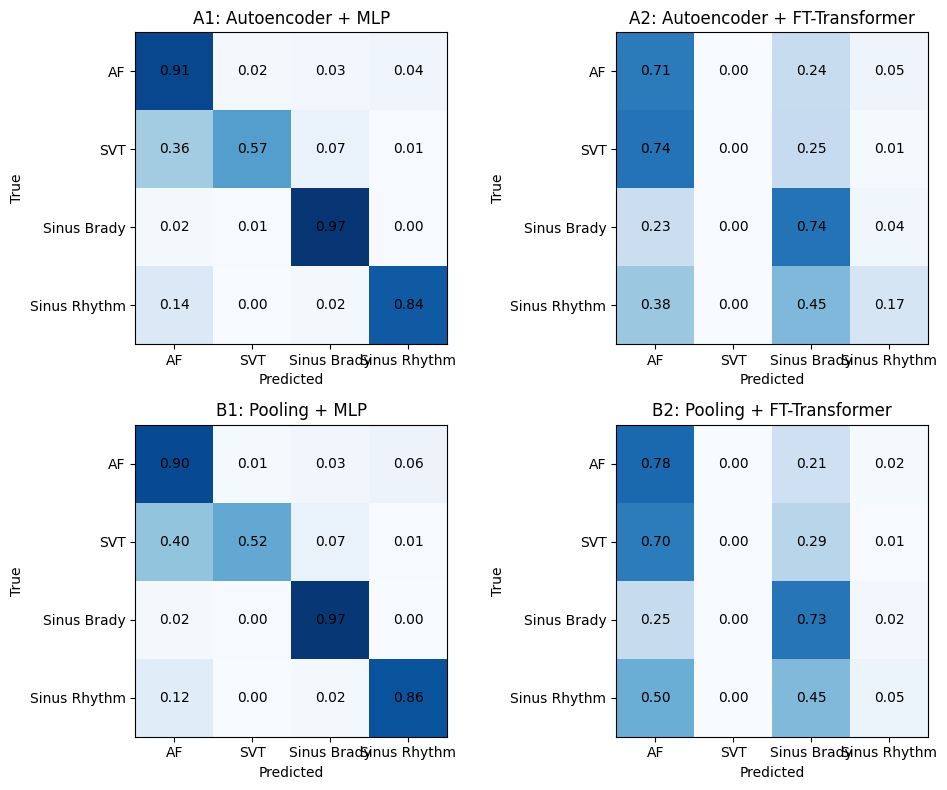

In [7]:
# Normalized (row) confusion matrices
if run_conditions:
    fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_cond == 1:
        axes2 = np.array([[axes2]])
    elif n_rows == 1:
        axes2 = axes2.reshape(1, -1)
    for idx, (cond_id, _) in enumerate(run_conditions):
        row, col = idx // n_cols, idx % n_cols
        ax = axes2[row, col]
        cm = all_results[cond_id]["confusion_matrix"]
        if cm is not None and cm.sum(axis=1).min() > 0:
            cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
            n = cm_norm.shape[0]
            ax.set_xticks(range(n))
            ax.set_yticks(range(n))
            ax.set_xticklabels(CLASS_NAMES)
            ax.set_yticklabels(CLASS_NAMES)
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
            for i in range(n):
                for j in range(n):
                    ax.text(j, i, "%.2f" % cm_norm[i, j], ha="center", va="center", color="black")
            ax.set_title(all_results[cond_id]["label"])
        else:
            ax.text(0.5, 0.5, "No CM", ha="center", va="center")
    for idx in range(n_cond, n_rows * n_cols):
        row, col = idx // n_cols, idx % n_cols
        axes2[row, col].set_visible(False)
    plt.tight_layout()
    plt.show()

## Split class distribution (support N per class)

Actual sample counts per class in validation and test sets. These are the Ns used for validation and test metrics above.

In [8]:
# Class counts on validation and test (from splits + labels)
try:
    from src.data import load_labels
    y_full = load_labels()
except FileNotFoundError:
    from src.data import load_raw_dataset
    _, y_full = load_raw_dataset()
if y_full.ndim == 2:
    y_idx = np.argmax(y_full, axis=1)
else:
    y_idx = y_full

y_val_split = y_idx[idx_val] if len(idx_val) > 0 else np.array([])
y_test_split = y_idx[idx_test]
n_classes = len(CLASS_NAMES)
val_supports = [int((y_val_split == c).sum()) for c in range(n_classes)]
test_supports = [int((y_test_split == c).sum()) for c in range(n_classes)]

df_support = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Validation N": val_supports,
    "Test N": test_supports,
})
print("Validation total: %d  |  Test total: %d" % (len(y_val_split), len(y_test_split)))
display(df_support)

Validation total: 2257  |  Test total: 6773


,Class,Validation N,Test N
0,AF,992,2969
1,SVT,60,162
2,Sinus Brady,811,2449
3,Sinus Rhythm,394,1193


## Ranking and export

Rank conditions by test weighted F1. Optionally export summary table to CSV for the paper.

In [9]:
# Rank by test weighted F1
if len(df_summary) > 0:
    df_ranked = df_summary.sort_values("Test weighted F1", ascending=False).reset_index(drop=True)
    df_ranked.insert(0, "Rank", range(1, len(df_ranked) + 1))
    print("Ranking by Test weighted F1:")
    display(df_ranked)
    # Optional: export to experiments folder for paper
    out_path = PROJECT_ROOT / "experiments" / "results_summary.csv"
    df_ranked.to_csv(out_path, index=False)
    print("\nExported to %s" % out_path)

Ranking by Test weighted F1:


,Rank,Condition,Test weighted F1,Val weighted F1
0,1,A1: Autoencoder + MLP,0.910274,0.902039
1,2,B1: Pooling + MLP,0.908806,0.904573
2,3,A2: Autoencoder + FT-Transformer,0.576950,0.561894
3,4,B2: Pooling + FT-Transformer,0.560937,0.550094



Exported to C:\Projects\DeepLearningProject\experiments\results_summary.csv
